# 01 — Exploratory Data Analysis

Amazon Fine Food Reviews · Binary sentiment classification

Questions answered:
1. Class balance (positive vs negative)
2. Average review length by class
3. Null / missing value count
4. Top words per class

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from preprocess import load_and_binarize, clean_text, remove_stopwords

sns.set_theme(style='whitegrid')
%matplotlib inline

## 1 · Load data

In [2]:
df = load_and_binarize('../data/raw/Reviews.csv')
print(f'Total rows: {len(df):,}')
df.head()

Total rows: 525,814


,Text,label
0,I have bought several of the Vitality canned d...,positive
1,Product arrived labeled as Jumbo Salted Peanut...,negative
2,This is a confection that has been around a fe...,positive
3,If you are looking for the secret ingredient i...,negative
4,Great taffy at a great price. There was a wid...,positive


## 2 · Null check

In [3]:
print('Null counts:')
print(df.isnull().sum())

Null counts:
Text     0
label    0
dtype: int64


## 3 · Class balance

label
positive    443777
negative     82037

Percentages:
label
positive    84.4
negative    15.6


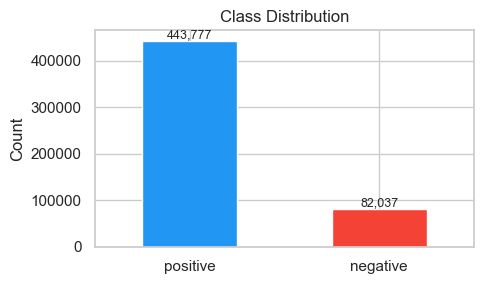

In [4]:
counts = df['label'].value_counts()
pct    = df['label'].value_counts(normalize=True) * 100

print(counts.to_string())
print('\nPercentages:')
print(pct.round(1).to_string())

fig, ax = plt.subplots(figsize=(5, 3))
counts.plot(kind='bar', ax=ax, color=['#2196F3', '#F44336'], edgecolor='white')
ax.set_title('Class Distribution')
ax.set_xlabel('')
ax.set_ylabel('Count')
ax.set_xticklabels(counts.index, rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 4 · Average review length by class

Mean character length by class:
label
negative    482.6
positive    419.6
Name: char_length, dtype: float64

Mean word count by class:
label
negative    88.3
positive    77.3
Name: word_count, dtype: float64


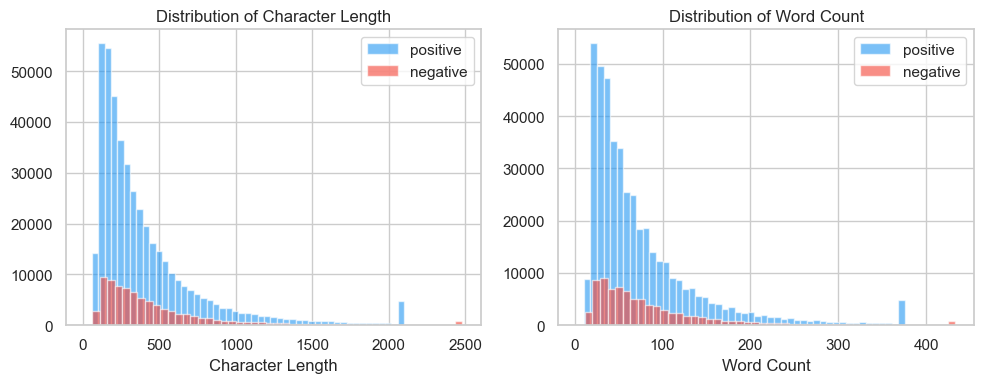

In [5]:
df['char_length'] = df['Text'].str.len()
df['word_count']  = df['Text'].str.split().str.len()

print('Mean character length by class:')
print(df.groupby('label')['char_length'].mean().round(1))
print('\nMean word count by class:')
print(df.groupby('label')['word_count'].mean().round(1))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col, title in zip(axes, ['char_length', 'word_count'],
                           ['Character Length', 'Word Count']):
    for label, color in zip(['positive', 'negative'], ['#2196F3', '#F44336']):
        subset = df[df['label'] == label][col]
        ax.hist(subset.clip(upper=subset.quantile(0.99)),
                bins=50, alpha=0.6, label=label, color=color)
    ax.set_title(f'Distribution of {title}')
    ax.set_xlabel(title)
    ax.legend()

plt.tight_layout()
plt.show()

## 5 · Top words per class

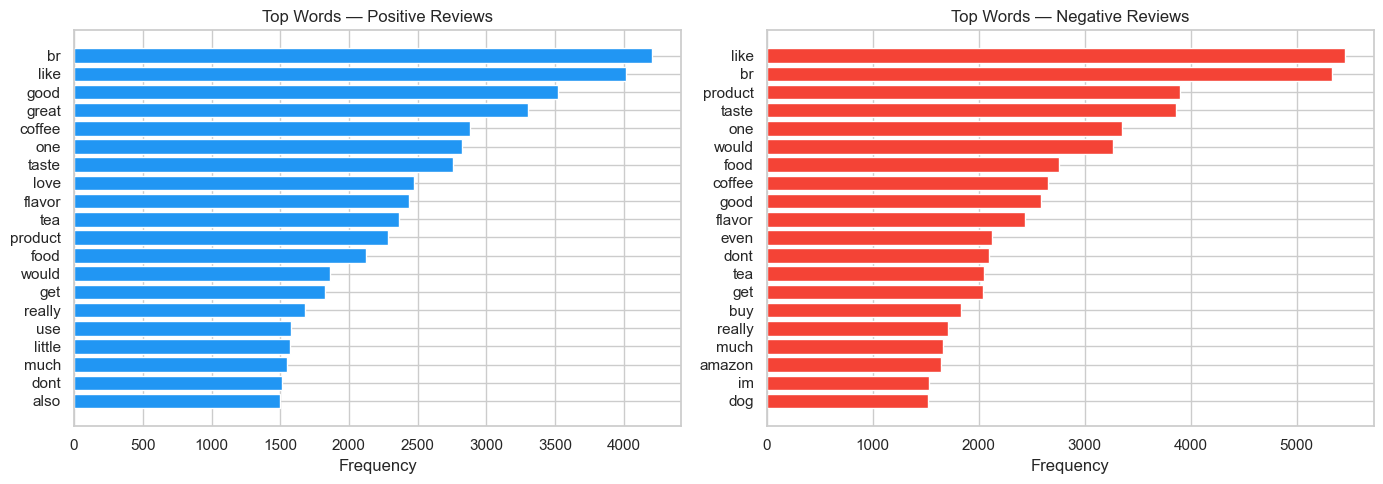

In [6]:
# Sample 10 000 reviews per class for speed
def top_words(df_class, n=20):
    sample = df_class['Text'].sample(min(10_000, len(df_class)), random_state=42)
    tokens = sample.apply(lambda t: remove_stopwords(clean_text(str(t)))).str.split()
    all_words = [w for tokens_list in tokens for w in tokens_list]
    return Counter(all_words).most_common(n)

pos_words = top_words(df[df['label'] == 'positive'])
neg_words = top_words(df[df['label'] == 'negative'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, words, title, color in zip(
    axes,
    [pos_words, neg_words],
    ['Top Words — Positive Reviews', 'Top Words — Negative Reviews'],
    ['#2196F3', '#F44336'],
):
    words_df = pd.DataFrame(words, columns=['word', 'count'])
    ax.barh(words_df['word'][::-1], words_df['count'][::-1], color=color)
    ax.set_title(title)
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.show()

## 6 · SQL demo — load via SQLite

In [7]:
import sqlite3

conn = sqlite3.connect('../data/raw/database.sqlite')
sql_df = pd.read_sql_query(
    'SELECT Score, COUNT(*) AS cnt FROM Reviews GROUP BY Score ORDER BY Score',
    conn
)
conn.close()
print('Score distribution (via SQL):')
sql_df

Score distribution (via SQL):


,Score,cnt
0,1,52268
1,2,29769
2,3,42640
3,4,80655
4,5,363122
